# Lab 12 — Real Robot Localization

Same Bayes filter as `sim_demo.ipynb`, but the BLE round-trip goes to a real Artemis instead of `SimRobot`. Each `DriveUpdate` returns the latest cached ToF samples plus the yaw at sample time, and we feed that straight into `Localization2D.predict / update`.

Before running:
1. Power the robot, place it at the known start pose with a known initial heading.
2. The MAC address + UUIDs come from `ble_robot_1.4/main_python/ble/connection.yaml`.
3. The IMU yaw will be snapped to `START_THETA_DEG` via `SetHeading` once connected, so the gyro-trusted assumption holds in the world frame.

## 1. Setup

In [1]:
%matplotlib inline
import sys, pathlib

SIM_DIR = pathlib.Path.cwd().parent          # labs/lab12/sim
BLE_DIR = SIM_DIR.parent / 'ble_robot_1.4'   # labs/lab12/ble_robot_1.4
for p in (SIM_DIR, BLE_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import asyncio, math
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from world import load_world
from localization2d import Localization2D
from controller import SplineController, BeliefPlot, filter_step, step_once
from real_robot import RealRobot
from paths import LAB_PATH_M

from main_python.ble.connection import BLEConnection
from main_python.commands import SetHeading, DriveSetAlignTol


In [2]:
# Frame recorder: copies the canvas RGBA on the main thread (fast),
# encodes PNG in a background pool, and stores per-frame wall-clock
# timestamps so the video stitches at real-time playback speed even
# when capture jitter (BLE round-trip variance, GC pauses, etc.)
# stretches some frames out longer than others.
import io, time, shutil, subprocess, threading
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import numpy as np
from PIL import Image


class FrameRecorder:
    def __init__(self, out_dir, max_workers=4, compress_level=1):
        self.out = Path(out_dir)
        if self.out.exists():
            shutil.rmtree(self.out)
        self.out.mkdir(parents=True, exist_ok=True)
        self._exe = ThreadPoolExecutor(max_workers=max_workers)
        self._compress = compress_level
        self.n = 0
        # Per-frame wall-clock capture times (seconds since the first
        # frame). Drives the ffmpeg concat-demuxer durations so the
        # output video plays back at real time.
        self.times: list[float] = []
        self.t0: float | None = None

    @staticmethod
    def _encode(path, rgba, compress):
        Image.fromarray(rgba).save(path, format="PNG", compress_level=compress)

    def capture(self, fig):
        # Force a draw, then copy the RGBA buffer (cheap memcpy).
        fig.canvas.draw()
        w, h = fig.canvas.get_width_height()
        rgba = np.asarray(fig.canvas.buffer_rgba()).copy()
        path = self.out / f"frame_{self.n:05d}.png"
        self.n += 1
        now = time.time()
        if self.t0 is None:
            self.t0 = now
        self.times.append(now - self.t0)
        self._exe.submit(self._encode, str(path), rgba, self._compress)

    def fps(self):
        if self.n < 2 or not self.times:
            return 30.0
        dt = max(1e-3, self.times[-1])
        return (self.n - 1) / dt

    def close(self):
        self._exe.shutdown(wait=True)

    def make_video(self, output_path, fps=None):
        """Stitch the captured frames at their real wall-clock cadence.

        Uses ffmpeg's concat demuxer with explicit per-frame durations
        derived from the capture timestamps, so a frame held on screen
        for 200 ms shows for 200 ms in the output. The trailing frame
        gets the median inter-capture interval since it has no
        successor to anchor against.
        """
        self.close()
        if self.n == 0:
            print("no frames recorded")
            return None
        output_path = str(output_path)

        intervals = [
            max(1e-3, self.times[i + 1] - self.times[i])
            for i in range(self.n - 1)
        ]
        # Trailing frame: pad with the median interval so it does not
        # flash by faster than its neighbours.
        if intervals:
            tail = float(np.median(intervals))
        else:
            tail = 1.0 / 30.0
        intervals.append(tail)

        list_path = self.out / "frames.txt"
        with open(list_path, "w") as f:
            for i, dur in enumerate(intervals):
                # The concat demuxer is picky: each non-final entry
                # needs `file` then `duration`; the final entry must
                # repeat the file with no trailing duration.
                f.write(f"file 'frame_{i:05d}.png'\n")
                f.write(f"duration {dur:.6f}\n")
            f.write(f"file 'frame_{self.n - 1:05d}.png'\n")

        cmd = [
            "ffmpeg", "-y",
            "-f", "concat", "-safe", "0",
            "-i", str(list_path),
            "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
            "-vsync", "vfr",
            "-c:v", "libx264", "-pix_fmt", "yuv420p",
            "-preset", "veryfast",
            output_path,
        ]
        total = self.times[-1] if self.times else 0.0
        avg_fps = (self.n / total) if total > 0 else 0.0
        print(f"stitching {self.n} frames over {total:.2f}s "
              f"(avg {avg_fps:.2f} fps) -> {output_path}")
        subprocess.run(cmd, check=True)
        return output_path


In [3]:
PATH = LAB_PATH_M
START_THETA_DEG  = 45.0
BLE_TIMEOUT_S    = 5.0
# Controller + filter knobs live in config/world.yaml.


## 2. Build localization, controller, and plot

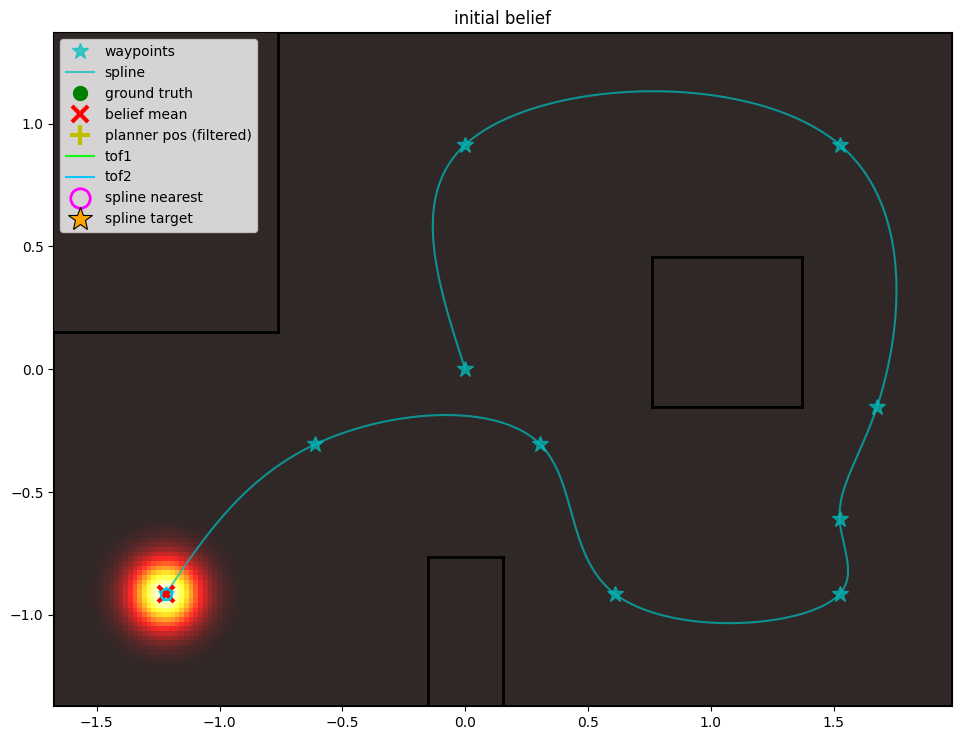

In [4]:
map_lines, bounds, loc_params, _, ctl_kwargs = load_world()
loc = Localization2D(map_lines, bounds, params=loc_params)
loc.init_at(PATH[0][0], PATH[0][1], sigma_m=0.10)
ctl = SplineController(path=PATH, loc=loc, map_lines=map_lines, **ctl_kwargs)
_, _spline_xy = ctl.spline.dense_sample(0.01)
plot = BeliefPlot(loc, map_lines, path=PATH, spline_xy=_spline_xy)
plot.update(None, type('R', (), {'tof1_dist_mm': 0, 'tof2_dist_mm': 0,
                                  'tof1_yaw_deg': 0, 'tof2_yaw_deg': 0})(),
            title='initial belief')
plt.show()


## 3. Connect and seed the gyro

Establishes the BLE link and snaps `imu::yaw` on the robot to `START_THETA_DEG`, so all subsequent `tof_yaw_deg` fields land in the world frame.

In [5]:
conn = BLEConnection()
await conn.connect()


In [6]:

await conn.execute(SetHeading(START_THETA_DEG), timeout=BLE_TIMEOUT_S)
# Push the host's heading-error rolloff sigma to the robot so its
# on-board Gaussian uses the same value the predict step assumes.
await conn.execute(DriveSetAlignTol(ctl.align_tol_deg), timeout=BLE_TIMEOUT_S)
robot = RealRobot(conn, timeout_s=BLE_TIMEOUT_S)
print('connected, heading set to', START_THETA_DEG, 'deg, align_tol =', ctl.align_tol_deg)


connected, heading set to 45.0 deg, align_tol = 30.0


[BLE] TX SetHeading req_id=1 cmd_id=53 (8 bytes)
[BLE] TX DriveSetAlignTol req_id=2 cmd_id=54 (8 bytes)


## 4. Stationary sanity check

Hold the robot still and run a few `DriveUpdate(speed=0, heading=0)` calls. The belief should sharpen around the true pose without driving anywhere; if it doesn't, the start pose, heading, or sensor sigma is off before you turn the motors on.

In [7]:
last_t_us = 0
rec = FrameRecorder('frames_real_stationary')
prev_resp = None
for i in range(20):
    task = asyncio.create_task(robot.update(target_speed=0.0, target_heading=START_THETA_DEG))
    if prev_resp is not None:
        bx, by = loc.mean_xy()
        print(f'i={i-1:2d}  bel=({bx:+.3f},{by:+.3f})  '
              f'tof1={prev_resp.tof1_dist_mm}mm@{prev_resp.tof1_yaw_deg:+.1f}  '
              f'tof2={prev_resp.tof2_dist_mm}mm@{prev_resp.tof2_yaw_deg:+.1f}')
        plot.update(None, prev_resp, title=f'stationary  i={i-1}')
        rec.capture(plot.fig)
    resp = await task
    last_t_us = resp.current_us
    filter_step(loc, resp)
    prev_resp = resp
# Render the final frame after the loop.
if prev_resp is not None:
    bx, by = loc.mean_xy()
    print(f'i=19  bel=({bx:+.3f},{by:+.3f})  '
          f'tof1={prev_resp.tof1_dist_mm}mm@{prev_resp.tof1_yaw_deg:+.1f}  '
          f'tof2={prev_resp.tof2_dist_mm}mm@{prev_resp.tof2_yaw_deg:+.1f}')
    plot.update(None, prev_resp, title='stationary  i=19')
    rec.capture(plot.fig)
rec.make_video('real_stationary.mp4')


[BLE] TX DriveSetAlignTol req_id=3 cmd_id=54 (8 bytes)
[BLE] TX DriveUpdate req_id=4 cmd_id=52 (17 bytes)


i= 0  bel=(-1.223,-0.923)  tof1=3190mm@+45.0  tof2=641mm@-45.0


[BLE] TX DriveUpdate req_id=5 cmd_id=52 (17 bytes)


i= 1  bel=(-1.225,-0.928)  tof1=3236mm@+45.0  tof2=639mm@-45.0
i= 2  bel=(-1.226,-0.931)  tof1=3216mm@+45.0  tof2=639mm@-45.0


[BLE] TX DriveUpdate req_id=6 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=7 cmd_id=52 (17 bytes)


...

i=14  bel=(-1.233,-0.945)  tof1=3263mm@+45.0  tof2=640mm@-45.0
i=15  bel=(-1.233,-0.946)  tof1=3179mm@+45.0  tof2=638mm@-45.0


[BLE] TX DriveUpdate req_id=20 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=21 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=22 cmd_id=52 (17 bytes)


i=16  bel=(-1.234,-0.947)  tof1=3139mm@+45.0  tof2=641mm@-45.0
i=17  bel=(-1.235,-0.948)  tof1=3227mm@+45.0  tof2=639mm@-45.0
i=18  bel=(-1.235,-0.949)  tof1=3227mm@+45.0  tof2=638mm@-45.0
i=19  bel=(-1.235,-0.950)  tof1=3230mm@+45.0  tof2=640mm@-45.0
stitching 20 frames over 1.79s (avg 11.16 fps) -> real_stationary.mp4


[BLE] TX DriveUpdate req_id=23 cmd_id=52 (17 bytes)
ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.4.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
-vsync is deprecated. Use -fps_mode
Input #0, concat, from 'frames_real_stationary/frames.txt':
  Duration: N/A, start: 0.000000, bitrate: N/A
  Stream #0:0:

'real_stationary.mp4'

## 5. Drive the path

Closed-loop: the controller picks `(speed, heading)` from the current belief mean, the robot drives one BLE round-trip, the filter updates, and we redraw. Stop with `Kernel → Interrupt` (the `finally` issues a `DriveUpdate(0, 0)` so the robot's drive timeout will zero the motors).

In [8]:
last_t_us = 0
last_yaw = START_THETA_DEG
step = 0
rec = FrameRecorder('frames_real_drive')
prev_resp = None
prev_step = 0
try:
    while not ctl.done:
        # Kick off the BLE round-trip in the background; render the
        # previous frame while it is in flight so the loop is not idle.
        # Frames are captured to disk only -- not shown inline -- so
        # the notebook's redraw cost does not throttle the control loop.
        task = asyncio.create_task(step_once(
            robot, loc, ctl,
            last_t_us=last_t_us, last_yaw_deg=last_yaw,
        ))
        if prev_resp is not None:
            plot.update(None, prev_resp,
                        title=f'step {prev_step}  s={ctl.s_prog:.2f}/{ctl.spline.S:.2f}m  '
                              f'yaw={prev_resp.yaw_deg:+.1f}deg  flip={ctl.flip}',
                        filtered_xy=(ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else None,
            nearest_xy=ctl.nearest_on_spline(*((ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else loc.mean_xy()))[1:],
            target_xy=ctl.target_xy())
            rec.capture(plot.fig)
        resp, last_t_us = await task
        last_yaw = resp.yaw_deg
        step += 1
        prev_resp = resp
        prev_step = step
    # Drain the last frame after the controller is done.
    if prev_resp is not None:
        plot.update(None, prev_resp,
                    title=f'step {prev_step}  s={ctl.s_prog:.2f}/{ctl.spline.S:.2f}m  '
                          f'yaw={prev_resp.yaw_deg:+.1f}deg  flip={ctl.flip}',
                    filtered_xy=(ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else None,
            nearest_xy=ctl.nearest_on_spline(*((ctl.filt_x, ctl.filt_y) if ctl.filt_x is not None else loc.mean_xy()))[1:],
            target_xy=ctl.target_xy())
        rec.capture(plot.fig)
finally:
    try:
        await robot.update(target_speed=0.0, target_heading=last_yaw)
    except Exception as e:
        print('shutdown update failed:', e)
    print(f'finished after {step} steps. final belief mean = {loc.mean_xy()}')
    rec.make_video('real_drive.mp4')


[BLE] TX DriveUpdate req_id=24 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=25 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=26 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=27 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=28 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=29 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=30 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=31 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=32 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=33 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=34 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=35 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=36 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=37 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=38 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=39 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=40 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=41 cmd_id=52 (17 bytes)
[BLE] TX DriveUpdate req_id=42 cmd_id=52 (17 bytes)
[BLE] TX Dri

finished after 207 steps. final belief mean = (-0.04216051123374446, -0.06059229011630299)
stitching 207 frames over 20.10s (avg 10.30 fps) -> real_drive.mp4


[out#0/mp4 @ 0x99f04c0c0] video:535KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.786237%
frame=  208 fps=0.0 q=-1.0 Lsize=     539KiB time=00:00:20.04 bitrate= 220.4kbits/s speed=38.7x elapsed=0:00:00.51    
[libx264 @ 0x99f049180] frame I:1     Avg QP:10.35  size: 25258
[libx264 @ 0x99f049180] frame P:55    Avg QP:17.50  size:  3843
[libx264 @ 0x99f049180] frame B:152   Avg QP:24.72  size:  2043
[libx264 @ 0x99f049180] consecutive B-frames:  1.0%  3.8%  2.9% 92.3%
[libx264 @ 0x99f049180] mb I  I16..4: 84.9%  1.4% 13.7%
[libx264 @ 0x99f049180] mb P  I16..4:  2.2%  0.3%  1.1%  P16..4:  1.5%  0.4%  0.3%  0.0%  0.0%    skip:94.2%
[libx264 @ 0x99f049180] mb B  I16..4:  0.2%  0.1%  0.2%  B16..8:  2.1%  0.7%  0.3%  direct: 0.6%  skip:95.9%  L0:45.7% L1:45.2% BI: 9.1%
[libx264 @ 0x99f049180] 8x8 transform intra:7.6% inter:11.3%
[libx264 @ 0x99f049180] coded y,uvDC,uvAC intra: 27.6% 43.1% 38.8% inter: 1.0% 1.2% 1.0%
[libx264 @ 0x99f049180] i16 v,h,dc,p:

## 6. Disconnect

In [9]:
await conn.disconnect()
print('disconnected')


disconnected
